In [1]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[1] / 'cloud_auto_park' / 'cloud_auto_park'
controls_path = Path('.').absolute().parents[0] / 'vehicle_controller'

sys.path.append(str(planning_path))
sys.path.append(str(controls_path))

from trajectory_utils import *
from mpc import *
import numpy as np
import time, pickle, time


In [2]:
trajectories_data_file = planning_path /'..' / 'analysis' / 'data' / 'trajectories.pkl'
trajectories = []
with open(str(trajectories_data_file), 'rb') as f:
    trajectories = pickle.load(f)


In [3]:
MIN_SPEED = 0.001

class VehiclePlantModel:
    
    def __init__(self, params: VehicleBicycleModelParams, major_sample_time_s=0.02, sample_time_s=0.005):
        self.params = params
        self.sample_time_s = sample_time_s
        self.major_sample_time_s = major_sample_time_s
        self.curr_state = np.array([[0.0], [0.0]])
        self.curr_pose = np.array([[0.0], [0.0], [0.0]])
        
    def get_a_b(self, vx_mps):
    
        if vx_mps >= 0: vx_mps = max(vx_mps, MIN_SPEED)
        else: vx_mps = min(vx_mps, -1*MIN_SPEED)
        abs_vx = abs(vx_mps)
        cf_Nprad = self.params.cf_Nprad
        cr_Nprad = self.params.cr_Nprad
        mass_kg = self.params.mass_kg
        lf_m = self.params.lf_m
        lr_m = self.params.lr_m
        izz_kgm2 = self.params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * abs_vx), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg*abs_vx) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*abs_vx), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*abs_vx) ]
        ])
        B = np.array([
            [(cf_Nprad*vx_mps)/(mass_kg*abs_vx)],
            [(cf_Nprad*lf_m*vx_mps)/(abs_vx*izz_kgm2)]
        ])
    
        return A, B
    
    def step_simulation(self, state, pose, delta, speed_mps):
        
        # using forward euler, may need to make this rk4 later
        A, B = self.get_a_b(speed_mps)
        state_dot = A @ state + B * delta
        state += state_dot * self.sample_time_s
        
        # get vx, vy, yaw rate, and update ego pose
        vx = speed_mps
        vy = state[0]
        yaw_rate = state[1]
        yaw = pose[2]
        
        vx_prime = vx*np.cos(yaw) - vy*np.sin(yaw)
        vy_prime = vx*np.sin(yaw) + vy*np.cos(yaw)
        
        pose_dot = np.array([vx_prime, vy_prime, yaw_rate])
        # print('plant pose dot', pose_dot)
        # print('=======')
        # print('plant pose', pose)
        pose += pose_dot * self.sample_time_s
        
        return state, pose
    
    def simulate_over_horizon(self, deltas, speeds_mps):
        
        N = len(deltas)
        for i in range(N):
            self.curr_state, self.curr_pose = self.step_simulation(self.curr_state, self.curr_pose, deltas[i], speeds_mps[i])
    
    def step(self, delta, speed_mps):
        num_timesteps = int(self.major_sample_time_s // self.sample_time_s)
        # print('num timesteps:', num_timesteps)
        deltas = [delta] * num_timesteps
        speeds = [speed_mps] * num_timesteps
        self.simulate_over_horizon(deltas, speeds)
        
    def get_curr_pose(self): return self.curr_pose
    def get_curr_state(self): return self.curr_state
        

In [4]:
# MPC PARAMS
actual_params = VehicleBicycleModelParams(cf_Nprad=3.30, cr_Nprad=3.80, mass_kg=2.62, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.062)
speed_mps = -1.0
sample_time_hz = 50
horizon = 5
delta_ff = []

lr = actual_params.lr_m
lf = actual_params.lf_m
m=actual_params.mass_kg
Iz = actual_params.izz_kgm2
cf = actual_params.cf_Nprad
cr = actual_params.cr_Nprad

fig_save_path = 'figures/doe/'

def plot_ego_traj(trajectory, stats, obstacles, desired_pose, metadata, num_intermediate_ego=30):
    
    def get_obstacle_patch(obb: OrientedBoundingBox, color='blue', alpha=0.6, linewidth=2):
        
        lower_left_x = obb.centroid_x_m - (obb.length_m / 2)
        lower_left_y = obb.centroid_y_m + (obb.width_m / 2)
        
        edgecolor, facecolor = '', ''
        if color == 'blue':
            edgecolor = 'blue'
            facecolor = 'lightblue'
        elif color == 'darkblue':
            edgecolor = 'darkblue'
            facecolor = 'blue'
        elif color == 'orange':
            edgecolor = 'red'
            facecolor = 'orange'
        elif color == 'red':
            edgecolor = 'darkred'
            facecolor = 'red'
        
        rect = matplotlib.patches.Rectangle(
            xy=(-lower_left_y, lower_left_x),
            width=obb.width_m,
            height=obb.length_m,
            angle=np.degrees(obb.heading_rad),
            rotation_point='center',  # Instructs matplotlib to rotate around the center
            edgecolor=edgecolor,
            facecolor=facecolor,
            alpha=alpha,
            linewidth=linewidth,
            zorder=-999
        )
        return rect
    
    fig, ax = plot_desired_path(trajectory, obstacles, num_intermediate_ego=0, plot_desired=False)
    ax.plot(-stats['y'], stats['x'], c='black', marker='o', markersize=2, label='Ego Vehicle Path')
    
    # plot intermediate ego vehicle obbs along the trajectory
    for ego_idx in range(num_intermediate_ego):
        N = len(stats['x'])
        path_idx = int((N-1) * ego_idx / (num_intermediate_ego - 1))
        # print(path_idx)
        
        intermediate_ego_obb = OrientedBoundingBox(stats['x'][path_idx], stats['y'][path_idx], desired_pose.length_m, desired_pose.width_m, stats['theta'][path_idx])
        intermediate_ego_rect = get_obstacle_patch(intermediate_ego_obb, 'blue', 0.15)
        ax.add_patch(intermediate_ego_rect)
    
    ax.legend()
    
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    filename = f"controls_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}_viz"
    filename = filename.replace('.', '-')
    fig.savefig(fig_save_path + filename + '.svg')
    
def plot_controls_stats(trajectory, stats, metadata):
    
    # abs(trajectories[0].headings - stats['theta'])
    x_vals = np.array(list(range(len(trajectory.headings)))) / sample_time_hz

    fig, ax = plt.subplots(4, sharex=True)
    fig.suptitle('Controls Metrics')
    ax[-1].set_xlabel('Time (s)')

    ds = np.sqrt(np.square(trajectory.path[0] - stats['x']) + np.square(trajectory.path[1] - stats['y']))
    ax[0].plot(x_vals, ds, label='Path Deviation (m)')
    ax[0].grid()

    # abs(trajectories[0].headings - stats['theta'])
    ax[1].plot(x_vals, trajectory.headings, label='Desired Heading (rad)')
    ax[1].plot(x_vals, stats['theta'], label='Actual Heading (rad)')
    ax[1].grid()

    ax[2].plot(x_vals, trajectory.curvatures * speed_mps, label='Desired Yaw Rates (rad/s)')
    ax[2].plot(x_vals, stats['omega'], label='Desired Yaw Rates (rad/s)')
    ax[2].grid()

    ax[3].plot(x_vals, stats['delta_ff'], label='Feedforward RWA (rad)')
    ax[3].plot(x_vals, stats['delta'], label='Actual RWA (rad)')
    ax[3].grid()

    for a in ax:
        a.legend()

    fig.set_size_inches(10, 8)
    fig.set_tight_layout(True)
    
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    filename = f"controls_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}_graphs"
    filename = filename.replace('.', '-')
    fig.savefig(fig_save_path + filename + '.svg')

def get_metrics(trajectory, stats, desired_pose):
    ds = np.sqrt(np.square(trajectory.path[0] - stats['x']) + np.square(trajectory.path[1] - stats['y']))
    dtheta = trajectory.headings - stats['theta']
    
    ego_traj = Trajectory(np.array([stats['x'], stats['y']]), stats['theta'], stats['omega']/speed_mps, [], desired_pose)
    min_sep = get_min_separation_between_traj_and_obs(ego_traj, desired_pose, 50)
    
    return {
        'mean_path_deviation': np.mean(ds),
        'max_path_deviation': np.max(ds),
        'final_path_deviation': ds[-1],
        'final_heading_deviation': dtheta[-1],
        'final_pose': [stats['x'][-1], stats['y'][-1], stats['theta'][-1]],
        'mean_solve_time': np.mean(stats['solve_times']),
        'max_solve_time': np.max(stats['solve_times']),
        'min_sep': min_sep
    }

def follow_trajectory_and_get_metrics(metadata):
    
    # unpack the metadata (trajectory, obstacles, desired pose)
    trajectory = metadata['traj']
    desired_pose, obstacles = setup_scenario(**metadata)
    
    # setup mpc controller
    mpc = MpcController(actual_params, sample_time_hz=25, horizon=horizon, speed_mps=speed_mps)
    mpc.set_path(trajectory.path, trajectory.headings, trajectory.curvatures)
    plant = VehiclePlantModel(actual_params, major_sample_time_s=(1/sample_time_hz))
    
    # step through number of timesteps in vehicle path
    curr_pose = np.array([[0.0], [0.0], [0.0]])

    # run through scenario and record stats
    xs, ys, thetas, deltas, omegas, solve_times = [], [], [], [], [], []
    for i in range(len(trajectory.curvatures)):
        
        # step controller
        mpc.set_curr_pose(curr_pose)
        start_time = time.process_time()
        curr_delta = mpc.step()
        end_time = time.process_time()
        
        # step plant
        plant.step(curr_delta, speed_mps)
        curr_pose = plant.get_curr_pose()
        curr_state = plant.get_curr_state()
        
        # save stats
        xs.append(float(curr_pose[0]))
        ys.append(float(curr_pose[1]))
        thetas.append(float(curr_pose[2]))
        omegas.append(float(curr_state[1]))
        deltas.append(float(curr_delta))
        solve_times.append(end_time - start_time)
        
    # put stats in a dict
    stats = {
        'x': np.array(xs),
        'y': np.array(ys),
        'theta': np.array(thetas),
        'omega': np.array(omegas),
        'delta': np.array(deltas),
        'delta_ff': np.array(mpc.ff_delta_history),
        'solve_times': np.array(solve_times)
    }
    
    # get metrics from stats
    metrics = get_metrics(trajectory, stats, desired_pose)
    
    # do plotting utils
    plot_controls_stats(trajectory, stats, metadata)
    plot_ego_traj(trajectory, stats, obstacles, desired_pose, metadata)
    
    return {
        'stats': stats,
        'metrics': metrics
    }


In [5]:
import itertools

def setup_scenario(gap_dist, x_sep, y_sep, is_left, is_wall, traj):
    
    obstacle_sep = gap_dist
    sign = 1 if is_left else -1
    obb_1 = OrientedBoundingBox(-x_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    obb_2 = OrientedBoundingBox(-x_sep - obstacle_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    wall = OrientedBoundingBox(-5.0, -sign * 2.5, 12.0, 1.0, 0.0)
    
    obstacles = [obb_1, obb_2]
    if is_wall: obstacles.append(wall)
    
    desired_pose = OrientedBoundingBox(-x_sep - (obstacle_sep / 2.0), sign * y_sep, 4.0, 2.0, -sign * math.pi/2)
    
    return desired_pose, obstacles


gap_dists = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
x_seps = [1.0, 2.0, 3.0, 4.0]
y_seps = [3.5, 4.0, 4.5, 5.0]
walls = [True, False]
directions = [True, False]
combinations = list(itertools.product(gap_dists, x_seps, y_seps, walls, directions))
print(len(combinations))

# setup all combinations for doe
scenarios = []
for idx, combo in enumerate(combinations):
    metadata = {
        'gap_dist': combo[0], 
        'x_sep': combo[1], 
        'y_sep': combo[2], 
        'is_left': combo[3], 
        'is_wall': combo[4],
        'traj': trajectories[idx]
    }
    scenarios.append(metadata)

for scenario in scenarios:
    desired_pose, obstacles = setup_scenario(**scenario)


384


{'stats': {'x': array([-0.02      , -0.04000002, -0.06000012, -0.08000041, -0.10000104,
         -0.1200022 , -0.14000405, -0.16000677, -0.18001052, -0.20001548,
         -0.22002181, -0.2400297 , -0.26003932, -0.28005086, -0.30006452,
         -0.32008052, -0.34009905, -0.36012033, -0.38014458, -0.40017202,
         -0.42020286, -0.44023732, -0.46027563, -0.48031801, -0.50036468,
         -0.52041584, -0.54047172, -0.56053251, -0.58059841, -0.60066963,
         -0.62074634, -0.64082874, -0.66091699, -0.68101126, -0.70111169,
         -0.72121843, -0.7413316 , -0.7614513 , -0.78157763, -0.80171067,
         -0.82185046, -0.84199704, -0.86215041, -0.88231057, -0.90247746,
         -0.92265101, -0.94283113, -0.96301766, -0.98321045, -1.00340928,
         -1.0236139 , -1.04382402, -1.06403931, -1.08425937, -1.10448378,
         -1.12471205, -1.14494364, -1.16517795, -1.18541432, -1.20565199,
         -1.22589001, -1.24612721, -1.26636213, -1.28659304, -1.30681803,
         -1.32703509, -1

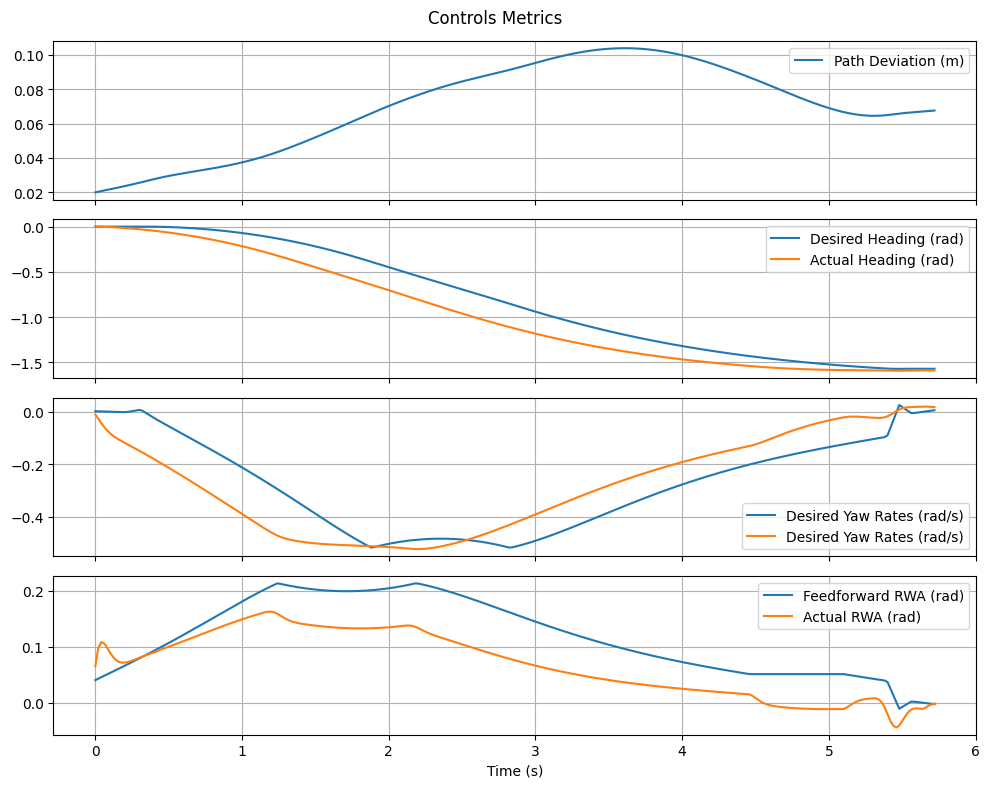

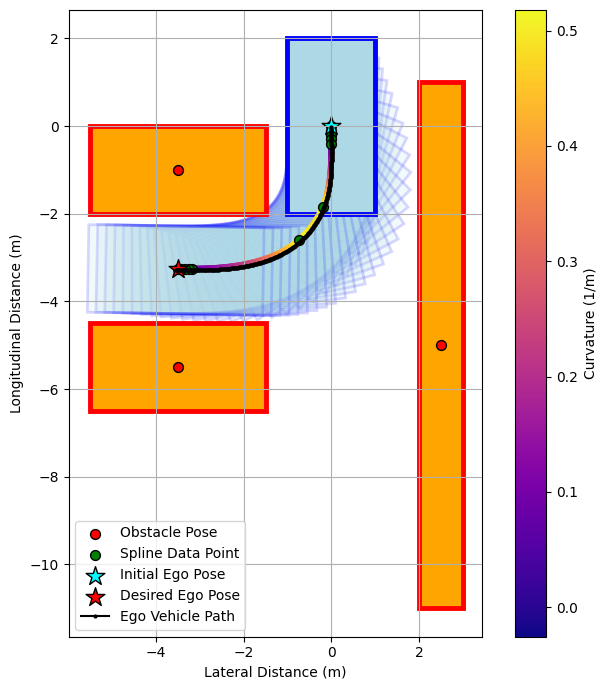

In [6]:
follow_trajectory_and_get_metrics(scenarios[0])


In [7]:
import multiprocessing as mp
import pickle

results = {}
run_doe = True

if run_doe:
    # Determine your system's core count
    cores = mp.cpu_count()

    with mp.Pool(processes=cores) as pool:
        results = pool.map(follow_trajectory_and_get_metrics, scenarios)

    # results = []
    # for scenario in scenarios:
    #     results.append(follow_trajectory_and_get_metrics(scenario))
    
    # save dataframe for future analysis
    with open(f'data/results.pkl', 'wb') as f:
        pickle.dump(results, f)



/tmp/ipykernel_253718/3089998033.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(4, sharex=True)
/tmp/ipykernel_253718/3089998033.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(4, sharex=True)
/tmp/ipykernel_253718/3089998033.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and ma